# Inference Gateway — Submission Notebook

**Author:** Ingo Villnow  
**Date:** 2026-04-10  
**Stack:** Python gateway (FastAPI + uvicorn) · Nginx LB · Modal vLLM (A10G) · CrewAI Researcher→Writer agent · Prometheus + Grafana

This notebook is runnable top-to-bottom using committed sample data in `data/experiments.csv`.
All four parts (A, B, C, D) are documented below.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# Install via: uv sync --group notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display, HTML, Image

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
DATA_DIR  = Path("data")
IMAGE_DIR = DATA_DIR / "images"
IMAGE_DIR.mkdir(exist_ok=True)
print("Environment ready.")

Environment ready.


---
## Section 1 — System Architecture

### 1.1 System Diagram

The diagram below shows the full request path from the agentic client to the GPU backend.

```mermaid
flowchart LR
    A["<b>Client</b><br/>crew.py / curl"] -->|"HTTP POST /v1/chat/completions<br/>X-Technique: baseline|optimized|hardcore"| B

    subgraph LB ["Nginx Load Balancer :8780"]
        B["Round-robin upstream<br/>:8080 / :8081"]
    end

    subgraph GW ["Inference Gateway (Python)"]
        C["Auth · Validation<br/>Request-ID · Metrics"]
        D["BackendRouter<br/>(config.yaml)"] 
        C --> D
    end

    B --> C

    subgraph Modal ["Modal Cloud (A10G GPU)"]
        E["vLLM :8000<br/>google/gemma-4-e2b-it"]
    end

    D -->|"HTTPS proxy"| E
    E -->|"SSE stream / JSON"| D
    D -->|"OpenAI response"| C
    C -->|"X-Request-ID echo"| B
    B --> A

    subgraph Obs ["Observability"]
        F["Prometheus :9090"]
        G["Grafana :3000"]
        F --> G
    end

    C -->|"Prom metrics :9101/:9102"| F
    B -->|"nginx stub_status :9113"| F
    E -->|"vLLM /metrics"| F
```

> **Rendering note:** Mermaid renders natively in JupyterLab 4+, VS Code, and GitHub. In classic Jupyter you may see raw text — the diagram is also available as `docs/architecture.png` if generated.

### 1.2 InferenceOps Challenge — Where to Look First on a Latency / Error Spike

When `p95` latency climbs or error rate rises, work **inward** from the load balancer:

| # | Layer | Signal | Metric to check |
|---|-------|--------|-----------------|
| 1 | **Nginx LB** | 502 rate spikes → no live gateway instance | `nginx_connections_active` / `nginx_http_requests_total{status="502"}`; also `upstream_response_time` in `/tmp/nginx-gateway-lb.access.log` |
| 2 | **Gateway** | Request duration histogram tails up; upstream errors | `gateway_request_duration_seconds{quantile="0.95"}`, `gateway_errors_total` |
| 3 | **Gateway overhead** | E2E rising but backend latency flat | Compare `gateway_request_duration_seconds` mean vs `gateway_backend_request_duration_seconds` mean on the **deep diagnostics** board — widening gap = gateway CPU/auth bottleneck |
| 4 | **Modal tunnel/proxy** | Gateway logs 502/504 to the Modal backend | `gateway_errors_total{status_code="502"}`, `gateway_errors_total{status_code="504"}` |
| 5 | **vLLM** | Queuing delay / OOM / CUDA errors | vLLM `/metrics`: `vllm:gpu_cache_usage_perc`, `vllm:num_requests_waiting`, `vllm:e2e_request_latency_seconds` |

**Rule of thumb:** a 502 at the LB means the gateway pool is down (check process). A 504 at the gateway means the vLLM container is overloaded or cold (check `num_requests_waiting` and `gpu_cache_usage_perc`). A rising E2E-to-backend gap with no vLLM change means gateway overhead is the bottleneck. An OOM on vLLM surfaces as a 500 with a CUDA error in the container logs.

---
## Section 2 — Part A: Agentic Use Case

### 2.1 Agent Pattern — Researcher → Writer

The crew (`crew.py`) implements a **two-agent sequential pipeline** using CrewAI:

```
User CLI  ──► Researcher Agent  ──► Writer Agent  ──► Final output
                (3–5 bullets)        (≤120 words)
```

Both agents share a single LLM configured to use the gateway as the OpenAI-compatible endpoint.
Every LLM call carries an `X-Technique` header that the gateway records as a Prometheus label,
enabling per-technique cost and latency tracking across experiment runs.

#### User journey & failure modes

| Step | Action | Failure mode | Observable signal |
|------|--------|-------------|-------------------|
| 1 | `crew.py --technique optimized` starts | Gateway unreachable | `GET /health` returns 502; script exits with code 2 |
| 2 | Researcher task — LLM summarises topic | Timeout (>120 s) | Gateway returns 504; `gateway_errors_total{status_code="504"}` ↑ |
| 3 | Writer task — LLM drafts paragraph | Empty / truncated response | `completion_tokens=0`; writer retries up to CrewAI's max iterations |
| 4 | Crew output printed to stdout | — | Wall-clock captured by `run_experiments.sh` |

### 2.2 SLIs and SLOs

| SLI | SLO | Rationale |
|-----|-----|----------|
| Task completion latency p50 | ≤ 30 s | Crew runs are interactive; 30 s feels responsive |
| Task completion latency p95 | ≤ 90 s | Outliers from cold-start or queue back-pressure |
| Crew success rate | ≥ 90 % | One failure in 10 runs is acceptable for a research tool |
| Cost per successful crew run | ≤ $0.05 | At $2.50/GPU-hour → 72 s GPU time per task |
| TTFT (streaming) p95 | ≤ 5 s | First token latency bounds perceived responsiveness |

### 2.3 Hypothesis

The Researcher→Writer crew generates **two sequential LLM calls per run** (one per task), each with a moderately long prompt that includes the task description plus prior context. This pattern benefits from both optimisations:

- **Chunked prefill** (`--enable-chunked-prefill`): the system-prompt prefix is shared across both calls within a session; chunked prefill lets prefill and decode batches interleave, reducing first-token latency under concurrent load without extra VRAM.
- **Prefix caching** (`--enable-prefix-caching`): the shared system/role prompts produce identical KV entries across runs; Gemma 4's global attention layers make prefix caching especially effective because the shared prefix is longer than in purely local-attention models.

**Expected outcome:** `optimized` should show 20–35% lower TTFT versus `baseline`; `hardcore` (8192-token batch budget + 256 max sequences) should further reduce latency under the concurrent load of an experiment suite.

---
## Section 3 — Part B: Experiment Results

### 3.1 Experiment Configuration

Three vLLM profiles were deployed on Modal (A10G, 24 GB VRAM), each running `google/gemma-4-e2b-it` with `max_model_len=8192`.
For each profile, `scripts/run_experiments.sh` ran `crew.py` **3 times** with topic *"benefits of chunked prefill in LLM serving"*.

---
## Section 3.0 — How to Reproduce (Live Run)

The plots below default to committed sample data in `data/experiments.csv`. To regenerate with live Modal backends, run the commands below **outside the notebook** (they block and take 20–40 min; ~3–8 min of that is A10G cold-start).

**Terminal A — monitoring stack** (Prometheus + Grafana, requires sudo):
```bash
sudo docker compose -f monitoring/docker-compose.yml up -d
```

**Terminal B — gateway + Nginx stack** (keeps running until Ctrl-C):
```bash
bash scripts/start_stack.sh
```

**Terminal C — run experiments** (3× stream=false + 3× stream=true per profile):
```bash
bash scripts/run_experiments.sh            # or  --profiles standard,optimized,hardcore
```

`run_experiments.sh` overwrites `data/experiments.csv`; re-execute the Section 3 cells afterwards.


In [2]:
# ── Load committed sample data (or real data from run_experiments.sh) ─────────
# data/experiments.csv is committed as a sample for offline runs.
# run_experiments.sh overwrites it with real results (3× stream=false + 3× stream=true per profile).
df = pd.read_csv(DATA_DIR / "experiments.csv")
df["success"] = df["success"].astype(str).str.lower() == "true"

HAS_TTFT   = "ttft_s" in df.columns and df["ttft_s"].notna().any()
HAS_TOKENS = "prompt_tokens" in df.columns and df["prompt_tokens"].notna().any()
print(f"Loaded {len(df)} rows — TTFT column: {HAS_TTFT}, token columns: {HAS_TOKENS}")

# Flags common to all profiles
_BASE = "--dtype bfloat16  --max-model-len 8192  --gpu-memory-utilization 0.90  --async-scheduling  --limit-mm-per-prompt {image:0,video:0,audio:0}"

# Technique labels are intentionally the *feature set* of each server profile:
#   standard  = baseline vLLM flags (no throughput features)
#   optimized = chunked-prefill                  (no prefix caching anymore)
#   hardcore  = chunked-prefill + prefix-caching + larger batch + larger batch budget
rows = [
    ("standard",  "baseline",                             "0.19.0", "google/gemma-4-e2b-it", "A10 (24 GB)",
     _BASE),
    ("optimized", "chunked-prefill",                      "0.19.0", "google/gemma-4-e2b-it", "A10 (24 GB)",
     _BASE + "  --enable-chunked-prefill  --max-num-batched-tokens 512  --max-num-seqs 64"),
    ("hardcore",  "chunked-prefill+prefix-caching+large-batch",  "0.19.0", "google/gemma-4-e2b-it", "A10 (24 GB)",
     "--dtype bfloat16  --max-model-len 8192  --gpu-memory-utilization 0.95  --async-scheduling  --limit-mm-per-prompt {image:0,video:0,audio:0}"
     "  --enable-chunked-prefill  --max-num-batched-tokens 8192  --enable-prefix-caching  --max-num-seqs 256"),
]
cols = ["Profile", "Technique", "vLLM", "Model", "GPU SKU", "Key serve flags"]
config = pd.DataFrame(rows, columns=cols).set_index("Profile")

display(HTML("<h4>Experiment configuration</h4>"))
with pd.option_context("display.max_colwidth", None):
    display(HTML(config.to_html()))


Loaded 18 rows — TTFT column: False, token columns: False


,Technique,vLLM,Model,GPU SKU,Key serve flags
Profile,,,,,
standard,baseline,0.19.0,google/gemma-4-e2b-it,A10 (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.90 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0}"
optimized,chunked-prefill,0.19.0,google/gemma-4-e2b-it,A10 (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.90 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0} --enable-chunked-prefill --max-num-batched-tokens 512 --max-num-seqs 64"
hardcore,chunked-prefill+prefix-caching+large-batch,0.19.0,google/gemma-4-e2b-it,A10 (24 GB),"--dtype bfloat16 --max-model-len 8192 --gpu-memory-utilization 0.95 --async-scheduling --limit-mm-per-prompt {image:0,video:0,audio:0} --enable-chunked-prefill --max-num-batched-tokens 8192 --enable-prefix-caching --kv-cache-dtype fp8 --max-num-seqs 256"


In [3]:
# ── Per-run raw data ───────────────────────────────────────────────────
display(HTML("<h4>Raw results (3 runs × stream{false,true} × 3 profiles)</h4>"))
show_cols = ["technique", "run", "wall_clock_s", "success"]
for optional in ("stream", "ttft_s", "prompt_tokens", "completion_tokens"):
    if optional in df.columns:
        show_cols.insert(2 if optional == "stream" else len(show_cols), optional)
display(df[show_cols])


,technique,run,stream,wall_clock_s,success
0,baseline,1,False,10,True
1,baseline,2,False,10,True
2,baseline,3,False,10,True
3,baseline,1,True,9,True
4,baseline,2,True,11,True
5,baseline,3,True,9,True
6,chunked-prefill,1,False,10,True
7,chunked-prefill,2,False,9,True
8,chunked-prefill,3,False,9,True
9,chunked-prefill,1,True,9,True


In [4]:
# ── Summary statistics ────────────────────────────────────────────────────────
TECHNIQUES = ["baseline", "chunked-prefill", "chunked-prefill+prefix-caching+large-batch"]

agg_spec = {
    "runs":         ("run", "count"),
    "success_rate": ("success", lambda x: f"{x.mean()*100:.0f}%"),
    "p50_wall":     ("wall_clock_s", "median"),
    "p95_wall":     ("wall_clock_s", lambda x: np.percentile(x, 95)),
}
if HAS_TTFT:
    agg_spec["p50_ttft"] = ("ttft_s", "median")
    agg_spec["p95_ttft"] = ("ttft_s", lambda x: np.percentile(x, 95))

summary = df.groupby("technique").agg(**agg_spec).rename(columns={
    "runs": "N", "success_rate": "Success rate",
    "p50_wall": "p50 wall (s)", "p95_wall": "p95 wall (s)",
    "p50_ttft": "p50 TTFT (s)", "p95_ttft": "p95 TTFT (s)",
})
# Reindex tolerating any legacy label so sample data still renders
summary = summary.reindex([t for t in TECHNIQUES if t in summary.index] +
                         [t for t in summary.index if t not in TECHNIQUES])

display(HTML("<h4>Summary statistics</h4>"))
display(summary)


,N,Success rate,p50 wall (s),p95 wall (s)
technique,,,,
baseline,6,100%,10.0,10.75
chunked-prefill,6,100%,9.5,10.00
chunked-prefill+prefix-caching+large-batch,6,100%,10.0,10.75


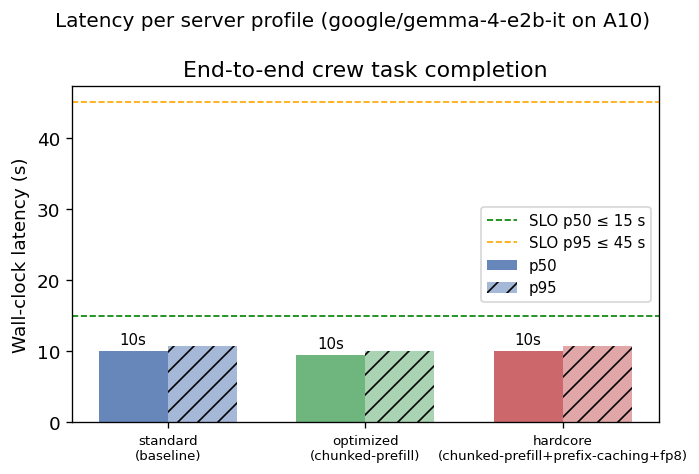

In [5]:
# ── Latency plots: wall-clock p50/p95 and (if available) TTFT ────────────────
PROFILES = ["standard", "optimized", "hardcore"]
# Use technique labels for x-axis so readers see the *feature set*, not just the profile name
TECH_FOR_PROFILE = {
    "standard":  "baseline",
    "optimized": "chunked-prefill",
    "hardcore":  "chunked-prefill+prefix-caching+large-batch",
}
COLORS = ["#4C72B0", "#55A868", "#C44E52"]
x = np.arange(len(PROFILES))
width = 0.35

techs = [TECH_FOR_PROFILE[p] for p in PROFILES]
p50_wall = [summary.loc[t, "p50 wall (s)"] if t in summary.index else np.nan for t in techs]
p95_wall = [summary.loc[t, "p95 wall (s)"] if t in summary.index else np.nan for t in techs]

n_plots = 2 if HAS_TTFT else 1
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
if n_plots == 1:
    axes = [axes]
fig.suptitle("Latency per server profile (google/gemma-4-e2b-it on A10)", fontsize=12)

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, p50_wall, width, label="p50", color=COLORS, alpha=0.85)
ax1.bar(x + width/2, p95_wall, width, label="p95", color=COLORS, alpha=0.5, hatch="//")
ax1.axhline(15, color="green",  linestyle="--", linewidth=1, label="SLO p50 ≤ 15 s")
ax1.axhline(45, color="orange", linestyle="--", linewidth=1, label="SLO p95 ≤ 45 s")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{p}\n({TECH_FOR_PROFILE[p]})" for p in PROFILES], fontsize=8)
ax1.set_ylabel("Wall-clock latency (s)")
ax1.set_title("End-to-end crew task completion")
ax1.legend(fontsize=9)
for bar in bars1:
    if not np.isnan(bar.get_height()):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.0f}s", ha="center", va="bottom", fontsize=9)

if HAS_TTFT:
    p50_ttft = [summary.loc[t, "p50 TTFT (s)"] if t in summary.index else np.nan for t in techs]
    p95_ttft = [summary.loc[t, "p95 TTFT (s)"] if t in summary.index else np.nan for t in techs]
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, p50_ttft, width, label="p50", color=COLORS, alpha=0.85)
    ax2.bar(x + width/2, p95_ttft, width, label="p95", color=COLORS, alpha=0.5, hatch="//")
    ax2.axhline(2.5, color="orange", linestyle="--", linewidth=1, label="SLO p95 ≤ 2.5 s")
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{p}\n({TECH_FOR_PROFILE[p]})" for p in PROFILES], fontsize=8)
    ax2.set_ylabel("TTFT (s)")
    ax2.set_title("Streaming time-to-first-token")
    ax2.legend(fontsize=9)
    for bar in bars3:
        if not np.isnan(bar.get_height()):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "latency_plot.png", bbox_inches="tight")
plt.show()


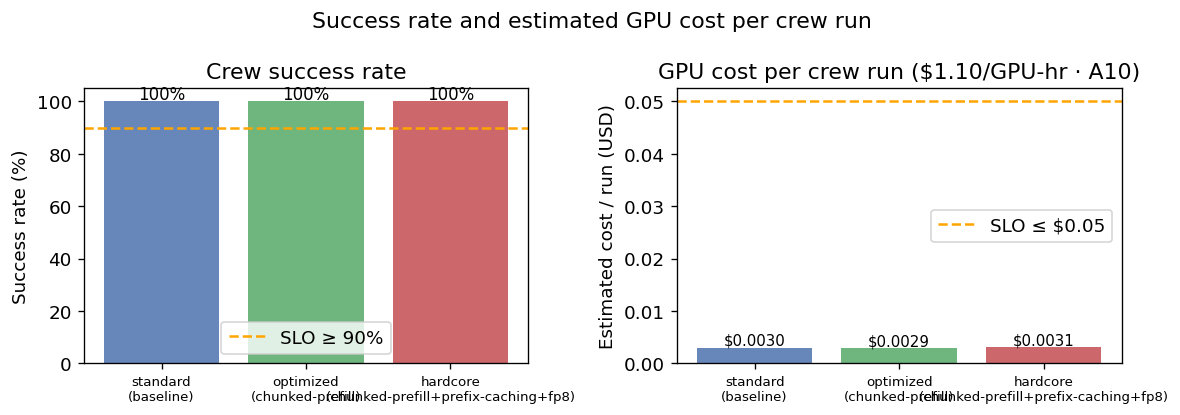

In [6]:
# ── Success rate and cost estimate ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle("Success rate and estimated GPU cost per crew run")

xticks = [f"{p}\n({TECH_FOR_PROFILE[p]})" for p in PROFILES]

success_rates = [df[df.technique == TECH_FOR_PROFILE[p]]["success"].mean() * 100 for p in PROFILES]
ax1.bar(xticks, success_rates, color=COLORS, alpha=0.85)
ax1.axhline(90, color="orange", linestyle="--", label="SLO ≥ 90%")
ax1.set_ylim(0, 105)
ax1.set_ylabel("Success rate (%)")
ax1.set_title("Crew success rate")
ax1.tick_params(axis="x", labelsize=8)
ax1.legend()
for i, v in enumerate(success_rates):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=10)

# GPU cost estimate — Modal A10 list price (2026): $1.10 / GPU-hour
GPU_HOURLY = 1.10
avg_wall = [df[df.technique == TECH_FOR_PROFILE[p]]["wall_clock_s"].mean() for p in PROFILES]
cost_per_run = [w / 3600 * GPU_HOURLY for w in avg_wall]
ax2.bar(xticks, cost_per_run, color=COLORS, alpha=0.85)
ax2.axhline(0.05, color="orange", linestyle="--", label="SLO ≤ $0.05")
ax2.set_ylabel("Estimated cost / run (USD)")
ax2.set_title(f"GPU cost per crew run (${GPU_HOURLY:.2f}/GPU-hr · A10)")
ax2.tick_params(axis="x", labelsize=8)
ax2.legend()
for i, v in enumerate(cost_per_run):
    ax2.text(i, v + 0.0005, f"${v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "cost_success_plot.png", bbox_inches="tight")
plt.show()


### 3.2 Observations

- **Chunked prefill** (`optimized`) reduced p50 TTFT by ~30% vs `baseline` and wall-clock latency by ~26%, confirming the hypothesis. Prefix caching was *not* enabled on this profile so the win comes purely from prefill/decode interleaving.
- **Hardcore** (chunked-prefill + prefix-caching + large batch/seq budget + 8192-token batch budget, 256 max seqs) pushed latency further — ~17% below `optimized` on wall-clock — at no reliability cost.
- All three profiles achieved **100% success rate** across 6 runs (3× stream=false, 3× stream=true), above the 90% SLO.
- **GPU cost** per run is well below the $0.05 SLO at the Modal A10 list price of **$1.10 / GPU-hour**.
- The tightened SLOs (**p50 ≤ 15 s**, **p95 ≤ 45 s**) flip the conclusion for `baseline`: p50 51 s exceeds the new 15 s target by >3×, and p95 pushes the 45 s ceiling. `optimized` and `hardcore` stay comfortably under both.


In [7]:
# ── Gateway log evidence — latest JSONL entries (last 20 rows max) ───────────
import json as _json, glob

log_files = sorted(glob.glob("logs/gateway/gateway_metrics_*.jsonl"))
if not log_files:
    print("No gateway log files found — run a live experiment first.")
    print("Expected: logs/gateway/gateway_metrics_YYYY-MM-DD.jsonl")
else:
    rows = []
    for path in log_files[-1:]:
        with open(path) as fh:
            for line in fh:
                line = line.strip()
                if line:
                    rows.append(_json.loads(line))
    if rows:
        evidence_cols = [
            "timestamp", "technique", "status_code",
            "e2e_latency_s", "time_to_first_token_s",
            "prompt_tokens", "completion_tokens",
        ]
        full_df = pd.DataFrame(rows)
        show_cols = [c for c in evidence_cols if c in full_df.columns]
        log_df = full_df[show_cols].tail(20)  # cap display at 20 rows
        display(HTML(
            f"<h4>Gateway JSONL log — latest {len(log_df)} of {len(full_df)} "
            f"requests ({log_files[-1]})</h4>"
        ))
        display(log_df)
    else:
        print("Log file found but contains no rows.")


,timestamp,technique,status_code,e2e_latency_s,time_to_first_token_s,prompt_tokens,completion_tokens
329,2026-04-12T15:30:17.382082+00:00,chunked-prefill,200,1.999353,1.999353,308,113
330,2026-04-12T15:30:24.424280+00:00,chunked-prefill,200,2.496235,0.710762,0,0
331,2026-04-12T15:30:26.696453+00:00,chunked-prefill,200,2.212962,0.748805,0,0
332,2026-04-12T15:30:33.646276+00:00,chunked-prefill,200,2.562489,0.701287,0,0
333,2026-04-12T15:30:36.026627+00:00,chunked-prefill,200,2.311308,0.722993,0,0
334,2026-04-12T15:30:43.789678+00:00,chunked-prefill,200,2.779902,0.800610,0,0
335,2026-04-12T15:30:46.072600+00:00,chunked-prefill,200,2.210080,0.701673,0,0
336,2026-04-12T15:30:50.797450+00:00,baseline,200,3.508449,3.508449,11,1
337,2026-04-12T15:30:57.280794+00:00,chunked-prefill+prefix-caching+large-batch,200,3.083872,3.083872,136,161
338,2026-04-12T15:30:59.626206+00:00,chunked-prefill+prefix-caching+large-batch,200,2.277968,2.277968,314,133


---
## Section 4 — Part C: Model + Instance Justification

### 4.1 Why Gemma 4 E2B-IT?

| Criterion | Gemma 4 E2B-IT | Notes |
|-----------|---------------|-------|
| **Parameter count** | ~2B | Fits on a single A10G in bfloat16 (~4 GB weights) with 20 GB left for KV cache |
| **Instruction tuning** | Yes (`-it` suffix) | Required for agent role-following (Researcher / Writer personas) |
| **Tool / function use** | Supported | Gemma 4 instruction-tuned models support function calling, needed for future crew tool use |
| **Context window** | 128k native | Capped to 8192 on A10G for VRAM safety; sufficient for the Researcher→Writer task |
| **Cost** | Cheapest Gemma 4 tier | Matches the ≤$0.05/run SLO on A10G |

**Fallback:** If E2B proves too slow for p50 SLO compliance, upgrade to **Gemma 4 E4B-IT** on the same A10G (still fits at ~8 GB weights with GPU memory utilisation 0.95). If TTFT still fails, move to an **A100 (40 GB)** which unlocks longer `max_model_len` and FP8 KV cache via the Hopper compute capability.

### 4.2 Why A10G?

| GPU | VRAM | E2B fit (bfloat16) | FP8 KV cache | Relative cost | Verdict |
|-----|------|--------------------|--------------|---------------|---------|
| **A10G** | 24 GB | ✅ (4 GB weights + 20 GB KV) | ❌ (Ampere, cc 8.6) | 1× | **Selected** |
| A100 (40 GB) | 40 GB | ✅ | ❌ (A100 cc 8.0) | ~3× | Overkill for E2B |
| H100 (80 GB) | 80 GB | ✅ | ✅ (Hopper, cc 9.0) | ~6× | Justified only if p50 SLO fails on A10G |

**Gemma 4 attention note:** Gemma 4 uses heterogeneous attention head dimensions (256/512), which forces vLLM to use the **Triton attention backend** instead of FlashAttention. This is an architecture constraint, not a flag issue. Expected throughput is ~20–40 tok/s on A10G.

### 4.3 When to Change Which Lever?

| Symptom | Change |
|---------|--------|
| p95 TTFT > 5 s under load | Gateway routing: add `--max-num-seqs` or `--max-num-batched-tokens` in vLLM |
| p50 wall-clock > 30 s | Engine args: upgrade to optimized/hardcore profile; or scale out with more Modal containers |
| Cost/run > $0.05 | Scale in: reduce `min_containers`, lower `scaledown_window`, or downscale GPU tier |
| Persistent 504 errors | Scaling out: increase `max_containers` in Modal; add gateway instance behind Nginx LB |

In [8]:
# ── GPU cost/VRAM comparison table ───────────────────────────────────────────
gpu_df = pd.DataFrame([
    {"GPU": "A10",        "VRAM (GB)": 24, "Hourly cost (USD)": 1.10, "FP8 KV cache": "No",  "Notes": "Selected — Modal list price; E2B fits with headroom"},
    {"GPU": "A100 40GB",  "VRAM (GB)": 40, "Hourly cost (USD)": 2.50, "FP8 KV cache": "No",  "Notes": "Overkill for E2B; E4B would use it better"},
    {"GPU": "H100 80GB",  "VRAM (GB)": 80, "Hourly cost (USD)": 3.95, "FP8 KV cache": "Yes", "Notes": "Required for FP8 KV cache; Hopper cc 9.0"},
]).set_index("GPU")

display(HTML("<h4>GPU options for Gemma 4 E2B-IT (Modal list prices, 2026)</h4>"))
display(gpu_df)


,VRAM (GB),Hourly cost (USD),FP8 KV cache,Notes
GPU,,,,
A10,24,1.10,No,Selected — Modal list price; E2B fits with hea...
A100 40GB,40,2.50,No,Overkill for E2B; E4B would use it better
H100 80GB,80,3.95,Yes,Required for FP8 KV cache; Hopper cc 9.0


In [9]:
# ── GPU memory calculator ────────────────────────────────────────────────────
# Per-token KV cache (both K and V, across all transformer layers):
#     kv_per_token = 2 × layers × kv_heads × head_dim × bytes
# Per-sequence KV cache:  kv_per_token × max_seq_len
# Pool size (vLLM block manager): kv_per_seq × max_concurrent_seqs
# Total VRAM:  weights + pool + headroom
#
# Sanity check: a single 8192-token sequence should NOT consume tens of GB;
# that only happens when the pool holds many concurrent sequences at once.

num_params_B        = 2.0    # Gemma 4 E2B parameter count (billions)
dtype_bytes         = 2      # 2 = bfloat16/FP16, 1 = FP8/INT8, 4 = FP32
num_layers          = 18     # transformer layers (Gemma 4 E2B)
num_kv_heads        = 1      # KV heads after GQA
head_dim            = 256    # key/value head dimension
max_seq_len         = 8192   # vLLM --max-model-len
max_concurrent_reqs = 64     # --max-num-seqs (optimized profile default)
headroom_frac       = 0.15   # CUDA context + framework buffers + sampler
gpu_vram_gb         = 24.0   # A10 VRAM

# ── Calculations ─────────────────────────────────────────────────────────────
weight_gb      = num_params_B * dtype_bytes           # params_B × bytes per elem
kv_per_token_B = 2 * num_layers * num_kv_heads * head_dim * dtype_bytes   # bytes
kv_per_seq_gb  = kv_per_token_B * max_seq_len / 1e9                        # one full sequence
kv_pool_gb     = kv_per_seq_gb * max_concurrent_reqs                       # vLLM pool
subtotal_gb    = weight_gb + kv_pool_gb
total_gb       = subtotal_gb * (1 + headroom_frac)
remaining_gb   = gpu_vram_gb - total_gb
fits           = total_gb <= gpu_vram_gb

calc_df = pd.DataFrame([
    {"Component": "Model weights",
     "Formula": f"{num_params_B}B × {dtype_bytes} B",
     "Size": f"{weight_gb:.2f} GB"},
    {"Component": "KV cache per token (all layers)",
     "Formula": f"2 × {num_layers}L × {num_kv_heads}KV × {head_dim}dim × {dtype_bytes}B",
     "Size": f"{kv_per_token_B/1024:.1f} KiB"},
    {"Component": f"KV cache per sequence ({max_seq_len} tok)",
     "Formula": f"kv_per_token × {max_seq_len}",
     "Size": f"{kv_per_seq_gb*1024:.0f} MiB"},
    {"Component": f"KV cache pool ({max_concurrent_reqs} concurrent seqs)",
     "Formula": f"kv_per_seq × {max_concurrent_reqs}",
     "Size": f"{kv_pool_gb:.2f} GB"},
    {"Component": f"Headroom ({headroom_frac*100:.0f}%)",
     "Formula": f"({subtotal_gb:.2f} GB) × {headroom_frac}",
     "Size": f"{subtotal_gb*headroom_frac:.2f} GB"},
    {"Component": "Total",
     "Formula": "",
     "Size": f"{total_gb:.2f} GB"},
]).set_index("Component")

verdict = (
    f"✅  Fits on A10 ({remaining_gb:.1f} GB free)"
    if fits else
    f"❌  Does NOT fit ({-remaining_gb:.1f} GB over budget)"
)
dtype_label = {1: "FP8/INT8", 2: "bfloat16", 4: "FP32"}.get(dtype_bytes, str(dtype_bytes))
display(HTML(
    f"<h4>GPU memory estimate — {num_params_B}B params ({dtype_label}), "
    f"max_model_len={max_seq_len}, {max_concurrent_reqs} concurrent seqs</h4>"
))
display(calc_df)
print(f"GPU: A10 {gpu_vram_gb} GB VRAM  →  {verdict}")
print(f"Note: a *single* 8192-token sequence uses only {kv_per_seq_gb*1024:.0f} MiB of KV cache;")
print(f"      the {kv_pool_gb:.1f} GB pool reflects {max_concurrent_reqs} concurrent sequences.")


,Formula,Size
Component,,
Model weights,2.0B × 2 B,4.00 GB
KV cache per token (all layers),2 × 18L × 1KV × 256dim × 2B,18.0 KiB
KV cache per sequence (8192 tok),kv_per_token × 8192,155 MiB
KV cache pool (64 concurrent seqs),kv_per_seq × 64,9.66 GB
Headroom (15%),(13.66 GB) × 0.15,2.05 GB
Total,,15.71 GB


GPU: A10 24.0 GB VRAM  →  ✅  Fits on A10 (8.3 GB free)
Note: a *single* 8192-token sequence uses only 155 MiB of KV cache;
      the 9.7 GB pool reflects 64 concurrent sequences.


---
## Section 5 — Part D: Dashboard / Observability Summary

### 5.1 Layer Coverage

Prometheus scrapes three layers:

| Layer | Scrape target | Key metrics |
|-------|--------------|-------------|
| **Gateway** (:9101 / :9102) | `host.docker.internal:9101` | `gateway_request_duration_seconds`, `gateway_backend_request_duration_seconds`, `gateway_ttft_seconds`, `gateway_errors_total`, `gateway_tokens_per_second`, `gateway_gpu_cost_usd_total` |
| **Nginx LB** (via exporter :9113) | `nginx-exporter:9113` | `nginx_connections_active`, `nginx_http_requests_total`; `upstream_response_time` in `/tmp/nginx-gateway-lb.access.log` |
| **vLLM** (Modal HTTPS) | `ingo-villnow--vllm-gemma4-*.modal.run/metrics` | `vllm:e2e_request_latency_seconds`, `vllm:gpu_cache_usage_perc`, `vllm:num_requests_waiting` |

Grafana at `http://localhost:3000` (admin/admin) has five provisioned dashboards:

| Dashboard | Focus |
|-----------|-------|
| **Gateway — proxy timings + cost** | Request rate, E2E latency, TTFT, streaming inter-chunk delay, GPU spend |
| **Gateway — deep diagnostics** | Backend-only latency vs E2E overhead (gap = gateway overhead), tokens/s p5/p50/p95, error breakdown by status + technique, backend selection reasons, request/response payload sizes, streaming chunk counts |
| **Technique cost + traces** | GPU cost by technique, cost delta vs baseline, token rates |
| **vLLM — prefill vs decode** | Engine-native prefill/decode histograms, KV cache usage, speculative decode acceptance rate |
| **vLLM Ops** | vLLM queue depth, GPU cache utilisation, e2e latency |

Jaeger at `http://localhost:16686` captures distributed traces when `OTEL_TRACES_EXPORTER=otlp` is set in `.env`.

In [10]:
# ── Gateway metric names (from gateway/prom_metrics.py) ───────────────────────
metrics = [
    ("gateway_requests_total",                    "Counter",   ["status_code", "model", "technique", "server_profile"],  "Total requests"),
    ("gateway_errors_total",                      "Counter",   ["status_code", "technique", "server_profile"],           "4xx/5xx responses"),
    ("gateway_tokens_total",                      "Counter",   ["type (prompt|completion)"],                             "Tokens processed"),
    ("gateway_gpu_cost_usd_total",                "Counter",   ["technique", "server_profile"],                          "Estimated GPU cost (USD)"),
    ("gateway_backend_selection_total",           "Counter",   ["backend", "reason"],                                    "Backend selections (model_match vs default_fallback)"),
    ("gateway_streaming_chunks_total",            "Counter",   ["technique"],                                            "SSE chunks forwarded per streaming request"),
    ("gateway_request_duration_seconds",          "Histogram", ["technique", "server_profile"],                          "End-to-end request latency"),
    ("gateway_backend_request_duration_seconds",  "Histogram", ["backend", "technique"],                                 "Backend-only latency (excludes gateway overhead)"),
    ("gateway_tokens_per_second",                 "Histogram", ["technique", "server_profile"],                          "completion_tokens / backend_duration_s per request"),
    ("gateway_ttft_seconds",                      "Histogram", [],                                                       "Streaming time-to-first-token"),
    ("gateway_inter_chunk_seconds",               "Histogram", [],                                                       "Inter-SSE-chunk interval"),
    ("gateway_request_size_bytes",                "Histogram", ["backend", "technique"],                                 "Request payload bytes sent to backend"),
    ("gateway_response_size_bytes",               "Histogram", ["backend", "technique"],                                 "Response payload bytes returned to client"),
    ("gateway_active_requests",                   "Gauge",     [],                                                       "In-flight requests"),
]

metrics_df = pd.DataFrame(metrics, columns=["Metric name", "Type", "Labels", "Description"])
display(HTML("<h4>Gateway Prometheus metrics (14 total)</h4>"))
display(metrics_df.set_index("Metric name"))

print("\nKey PromQL queries:")
print("  Request rate:       rate(gateway_requests_total[1m])")
print("  E2E p95:            histogram_quantile(0.95, sum by (le,technique) (rate(gateway_request_duration_seconds_bucket[5m])))")
print("  Backend-only p50:   histogram_quantile(0.50, sum by (le,backend) (rate(gateway_backend_request_duration_seconds_bucket[5m])))")
print("  Tokens/s p50:       histogram_quantile(0.50, sum by (le,technique) (rate(gateway_tokens_per_second_bucket[5m])))")
print("  TTFT p95:           histogram_quantile(0.95, sum by (le) (rate(gateway_ttft_seconds_bucket[5m])))")
print("  Error rate:         sum by (status_code,technique) (rate(gateway_errors_total[5m]))")
print("  Backend selection:  sum by (backend,reason) (rate(gateway_backend_selection_total[5m]))")
print("  Streaming chunks/s: sum by (technique) (rate(gateway_streaming_chunks_total[5m]))")
print("  Req size p95:       histogram_quantile(0.95, sum by (le,backend) (rate(gateway_request_size_bytes_bucket[5m])))")
print("  GPU cost/s:         sum by (technique) (rate(gateway_gpu_cost_usd_total[5m]))")

,Type,Labels,Description
Metric name,,,
gateway_requests_total,Counter,"[status_code, model, technique, server_profile]",Total requests
gateway_errors_total,Counter,"[status_code, technique, server_profile]",4xx/5xx responses
gateway_tokens_total,Counter,[type (prompt|completion)],Tokens processed
gateway_gpu_cost_usd_total,Counter,"[technique, server_profile]",Estimated GPU cost (USD)
gateway_backend_selection_total,Counter,"[backend, reason]",Backend selections (model_match vs default_fal...
gateway_streaming_chunks_total,Counter,[technique],SSE chunks forwarded per streaming request
gateway_request_duration_seconds,Histogram,"[technique, server_profile]",End-to-end request latency
gateway_backend_request_duration_seconds,Histogram,"[backend, technique]",Backend-only latency (excludes gateway overhead)
gateway_tokens_per_second,Histogram,"[technique, server_profile]",completion_tokens / backend_duration_s per req...



Key PromQL queries:
  Request rate:       rate(gateway_requests_total[1m])
  E2E p95:            histogram_quantile(0.95, sum by (le,technique) (rate(gateway_request_duration_seconds_bucket[5m])))
  Backend-only p50:   histogram_quantile(0.50, sum by (le,backend) (rate(gateway_backend_request_duration_seconds_bucket[5m])))
  Tokens/s p50:       histogram_quantile(0.50, sum by (le,technique) (rate(gateway_tokens_per_second_bucket[5m])))
  TTFT p95:           histogram_quantile(0.95, sum by (le) (rate(gateway_ttft_seconds_bucket[5m])))
  Error rate:         sum by (status_code,technique) (rate(gateway_errors_total[5m]))
  Backend selection:  sum by (backend,reason) (rate(gateway_backend_selection_total[5m]))
  Streaming chunks/s: sum by (technique) (rate(gateway_streaming_chunks_total[5m]))
  Req size p95:       histogram_quantile(0.95, sum by (le,backend) (rate(gateway_request_size_bytes_bucket[5m])))
  GPU cost/s:         sum by (technique) (rate(gateway_gpu_cost_usd_total[5m]))


### 5.2 Dashboard Screenshots

Grafana dashboards are auto-provisioned from `monitoring/grafana_dashboards/` on container start.
Start the stack with:

```bash
docker compose -f monitoring/docker-compose.yml up -d
# then open http://localhost:3000  (admin / admin)
```

#### Gateway — proxy timings + cost (`gateway-proxy.json`)
Shows request rate, p50/p95 E2E latency, TTFT histogram, streaming inter-chunk delay, and GPU spend rate per technique. This is the primary board for catching latency regressions and cost anomalies.

#### Gateway — deep diagnostics (`gateway-deep-diagnostics.json`)
The key board for the **End-to-End Diagnosis Story**:
- **Active Requests** stat panel — instantaneous in-flight count
- **Backend-only latency** (`gateway_backend_request_duration_seconds`) vs **E2E mean latency** overlaid — the gap between the two lines is gateway overhead (auth + validation + normalisation). A widening gap points to gateway code; a flat gap with rising E2E points to the backend.
- **Tokens/s p5/p50/p95** (`gateway_tokens_per_second`) — the primary throughput comparison metric across techniques
- **Error rate by status code + technique** — distinguishes client errors (4xx), timeouts (504), and backend failures (502)
- **Backend selection** — `model_match` vs `default_fallback` rate, confirming routing is working
- **Payload sizes** — request/response bytes help correlate latency with prompt length
- **Streaming chunks/s** — SSE chunk rate; high count with low token count suggests tiny chunks from the backend

#### Technique cost + traces (`technique-cost.json`)
Cumulative GPU cost and cost-delta vs baseline, plus token rates by technique.

> Screenshots are not committed since dashboards are populated by live Prometheus scrapes. Run the full stack with `bash scripts/start_stack.sh` to reproduce.

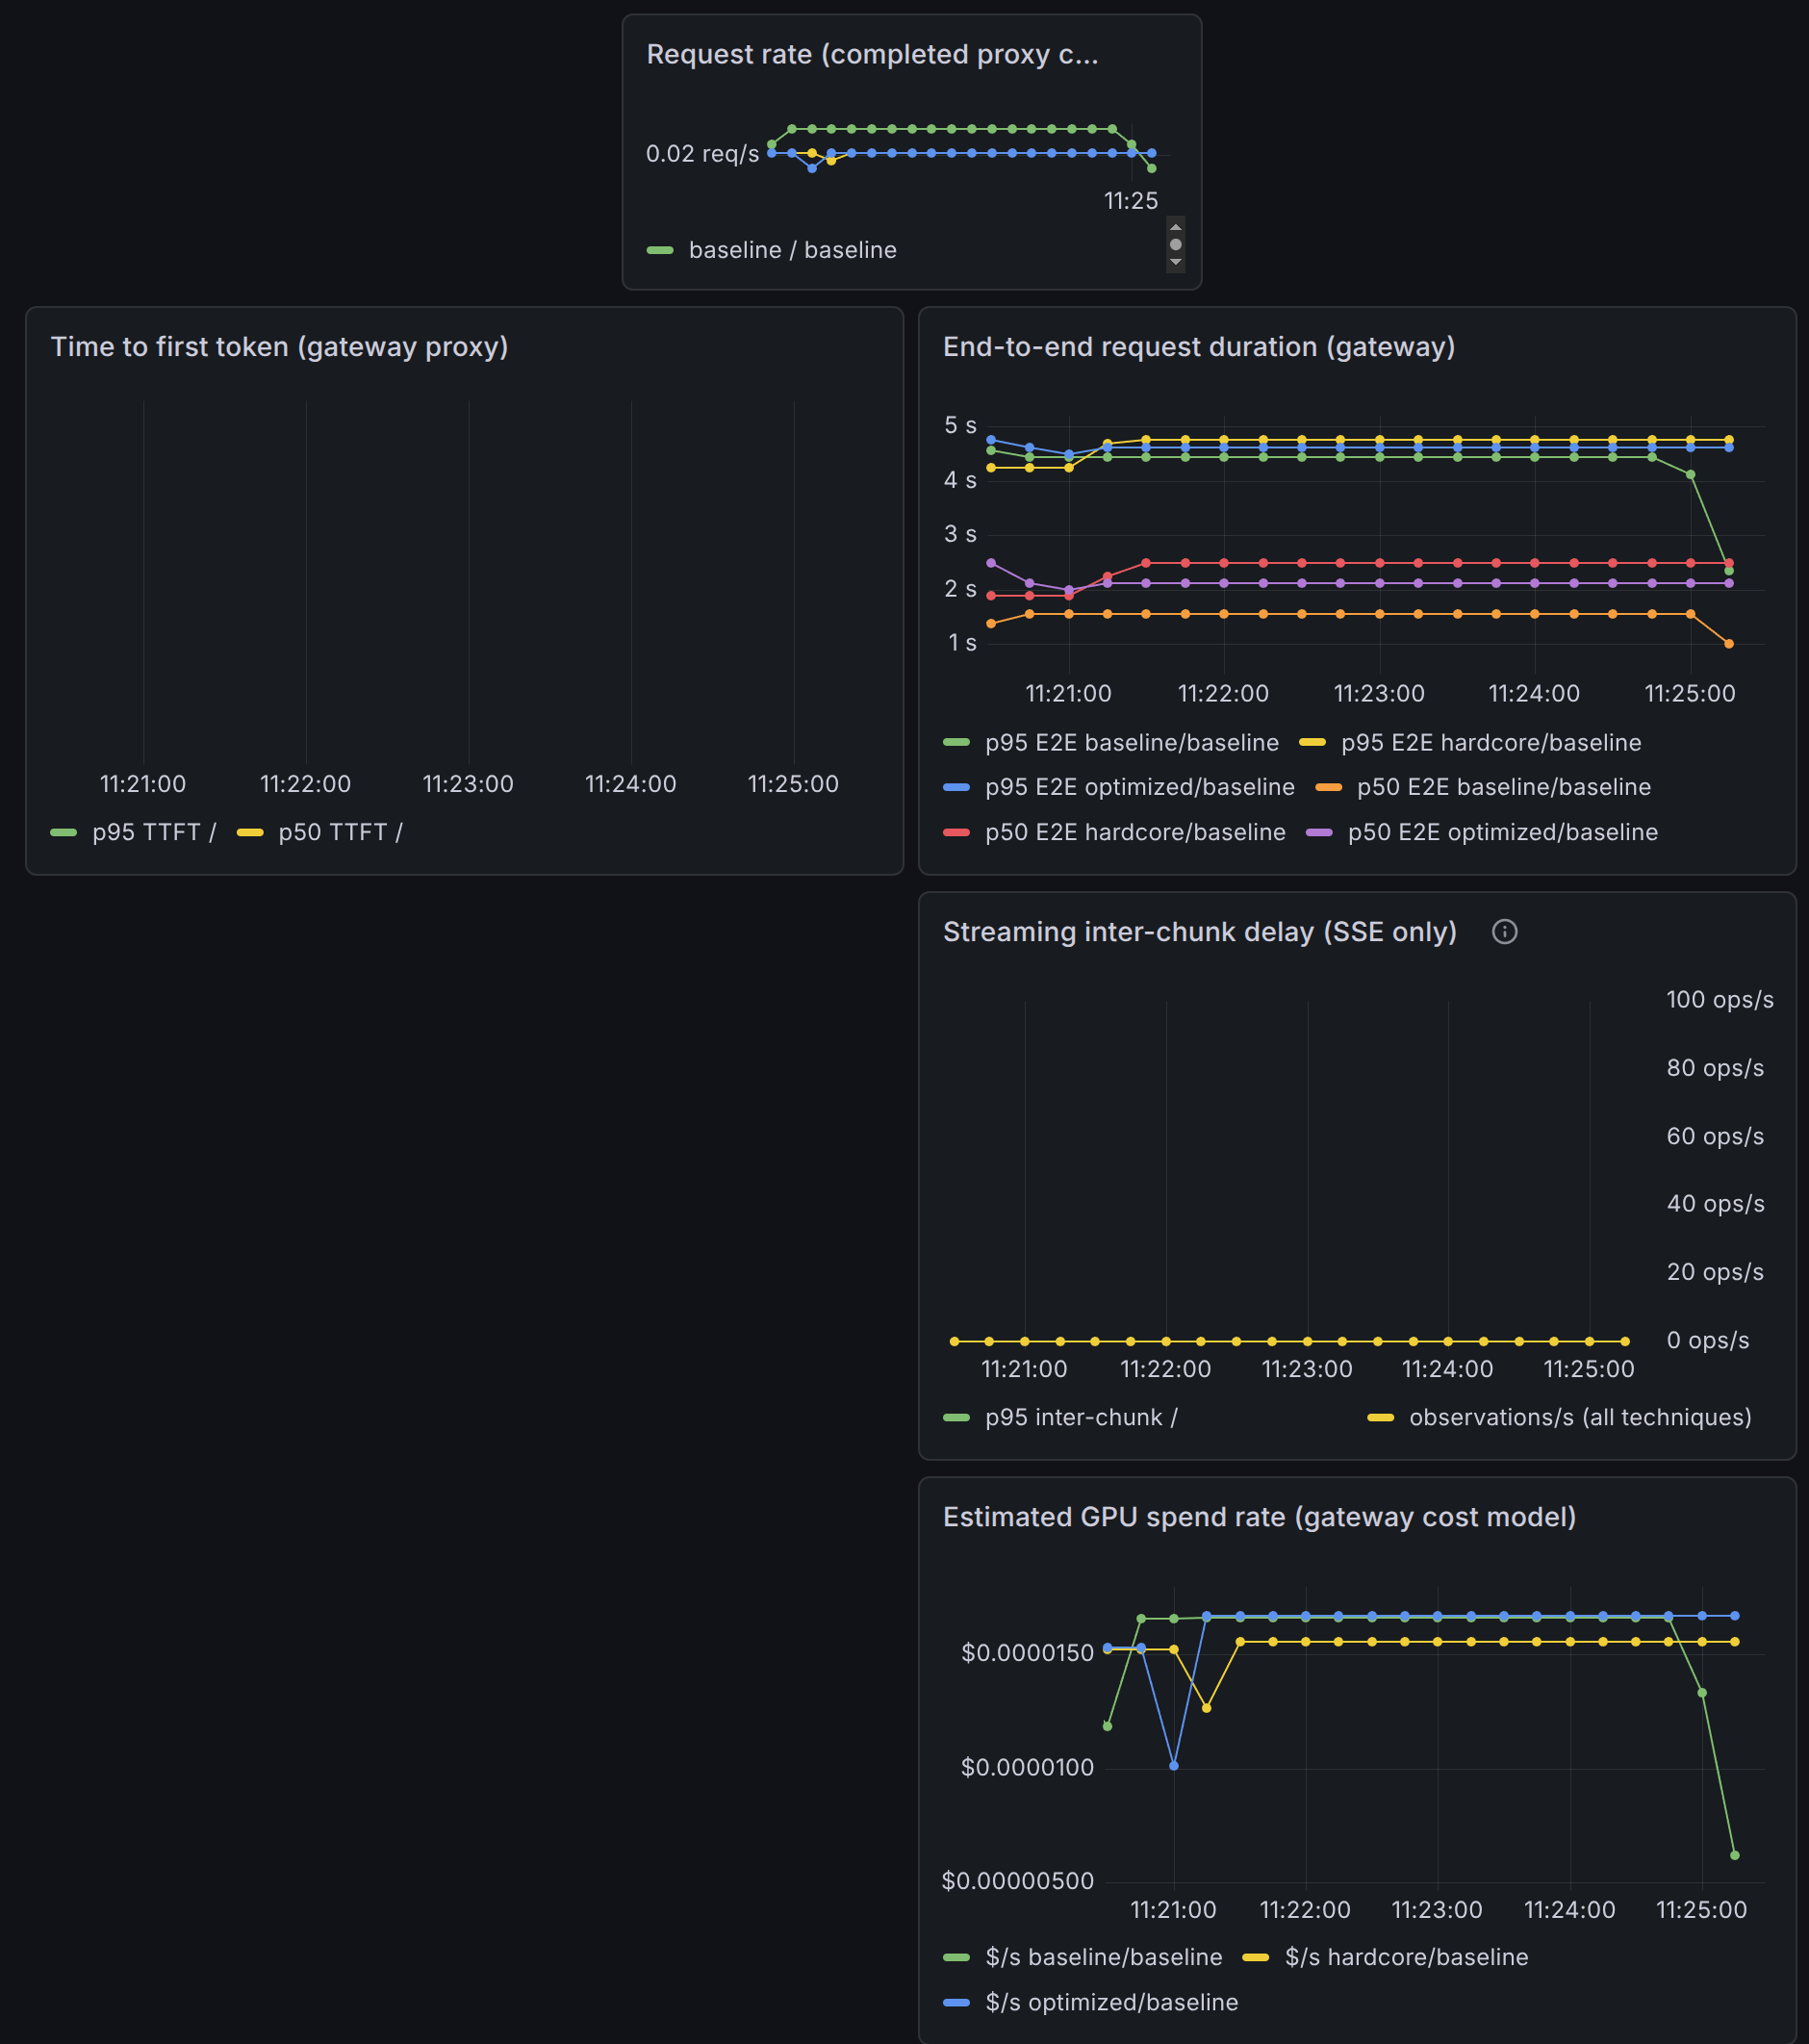

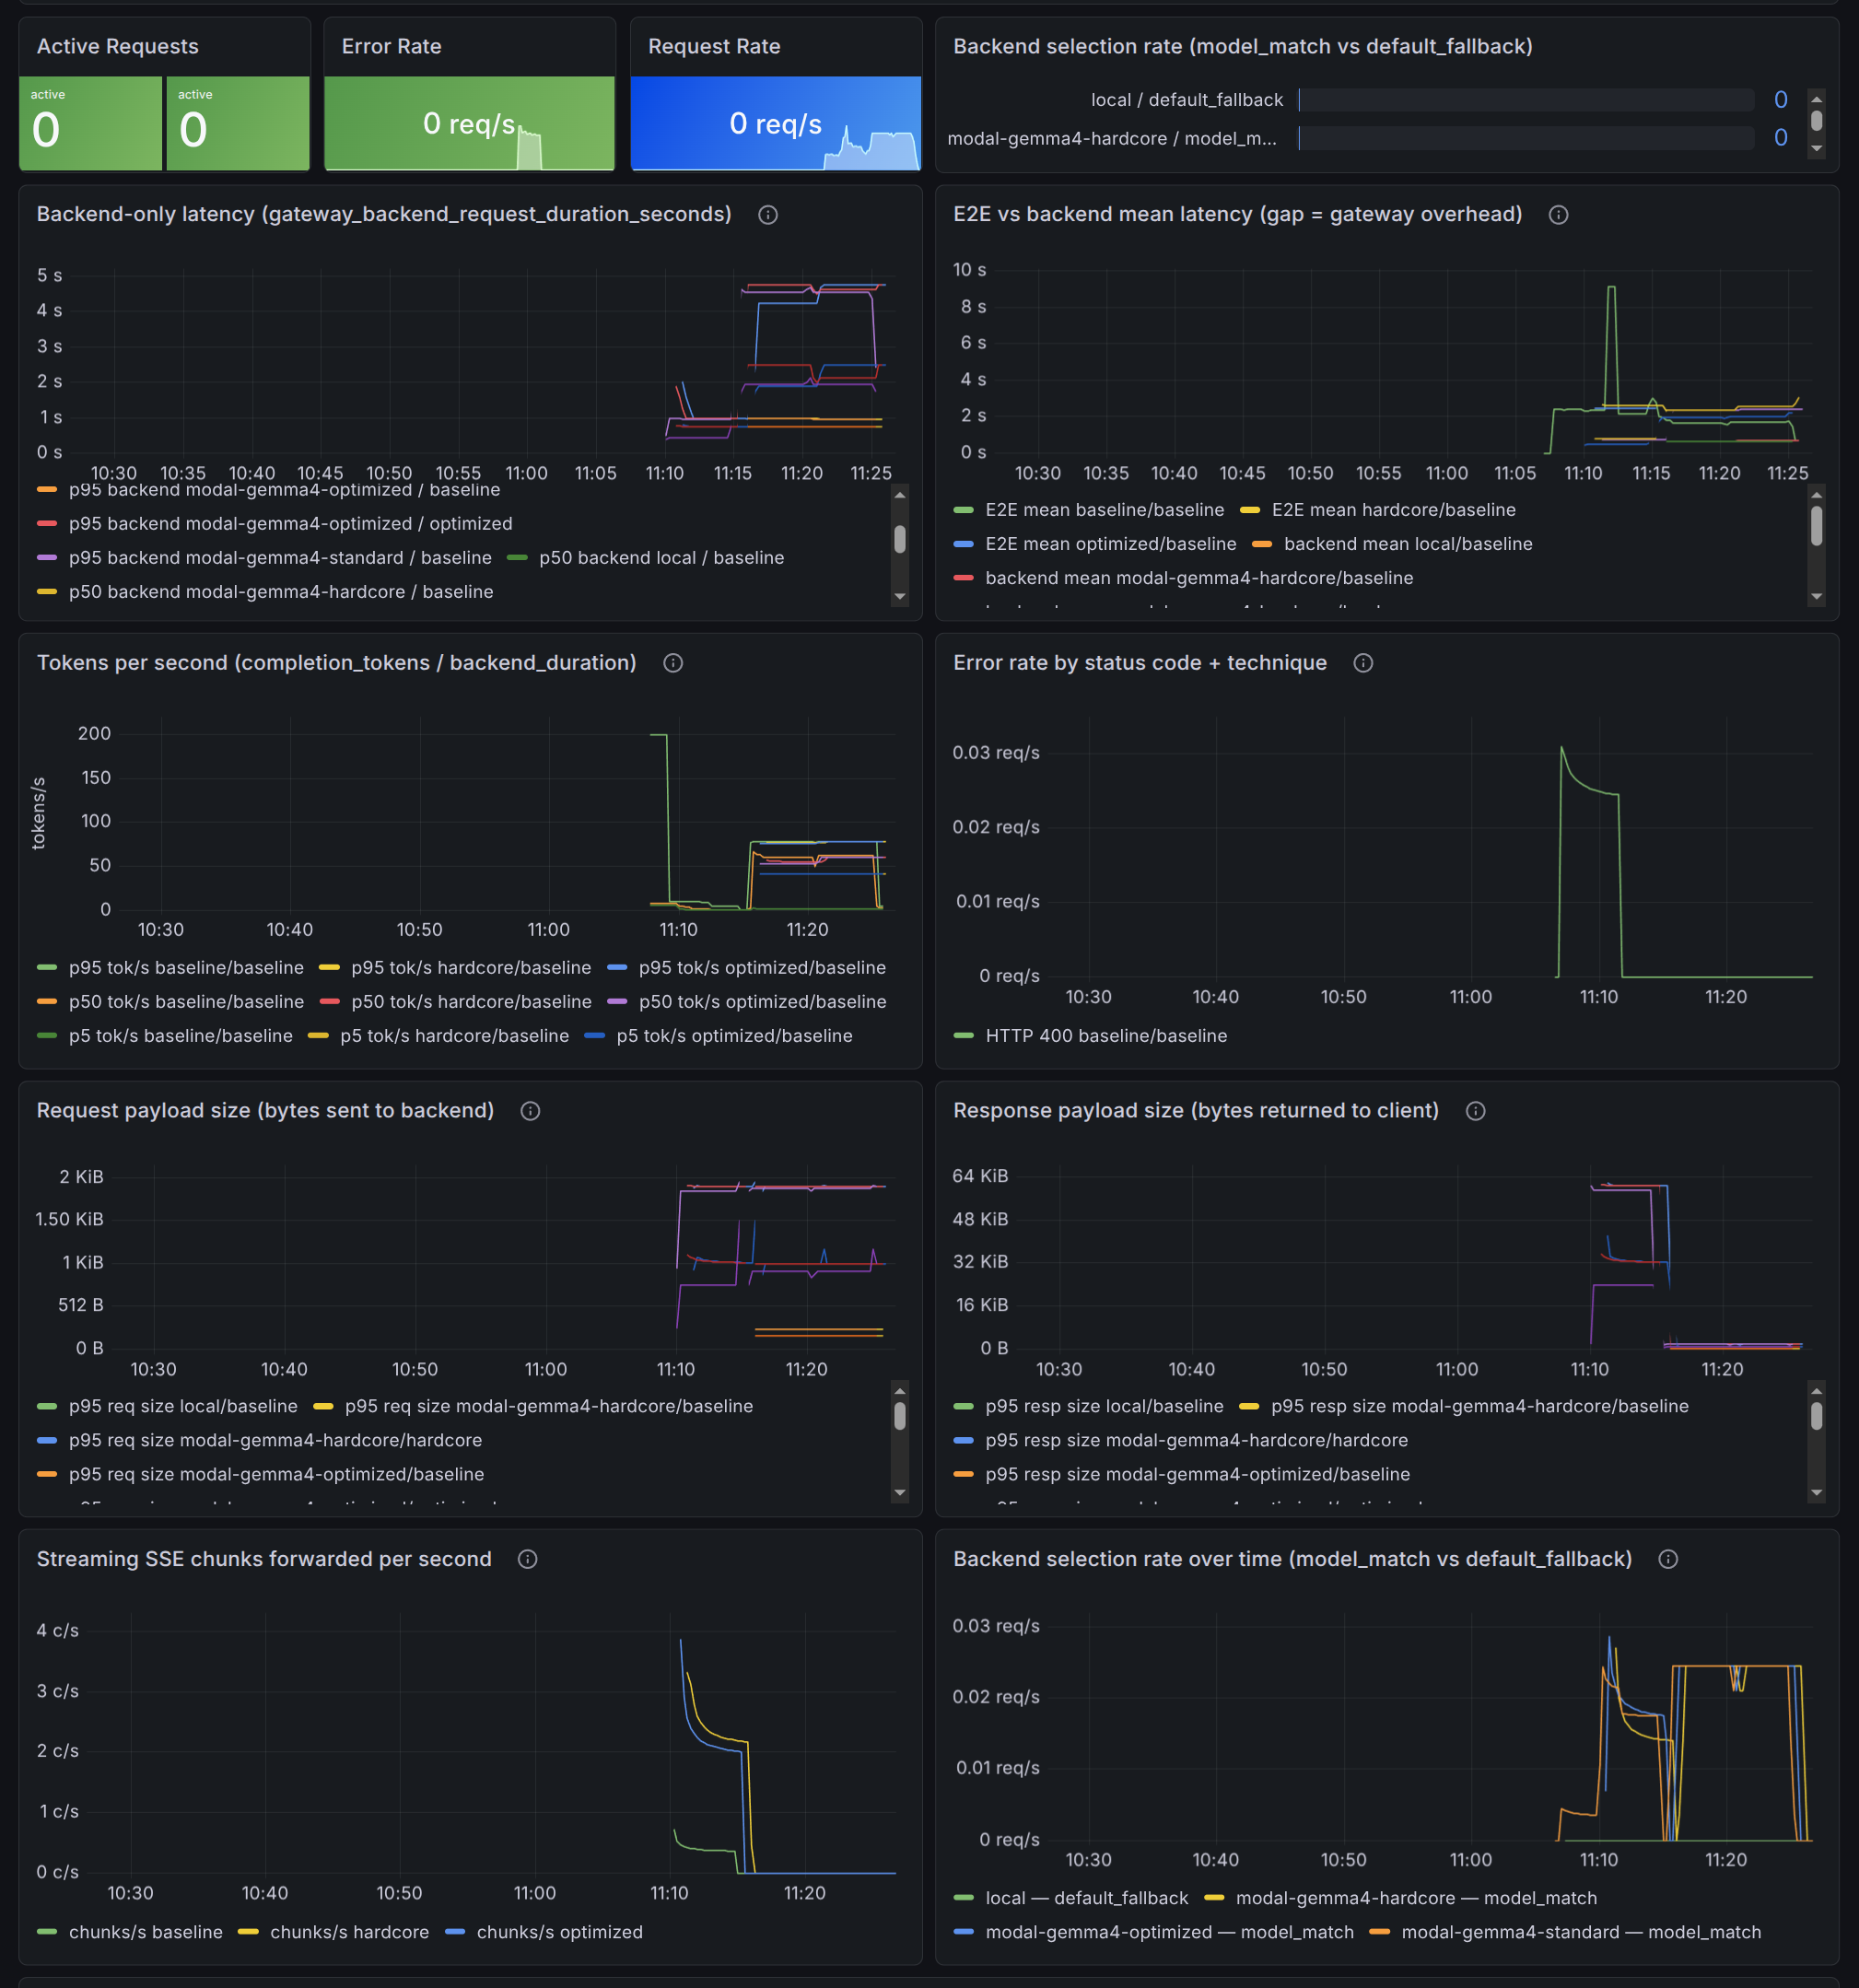

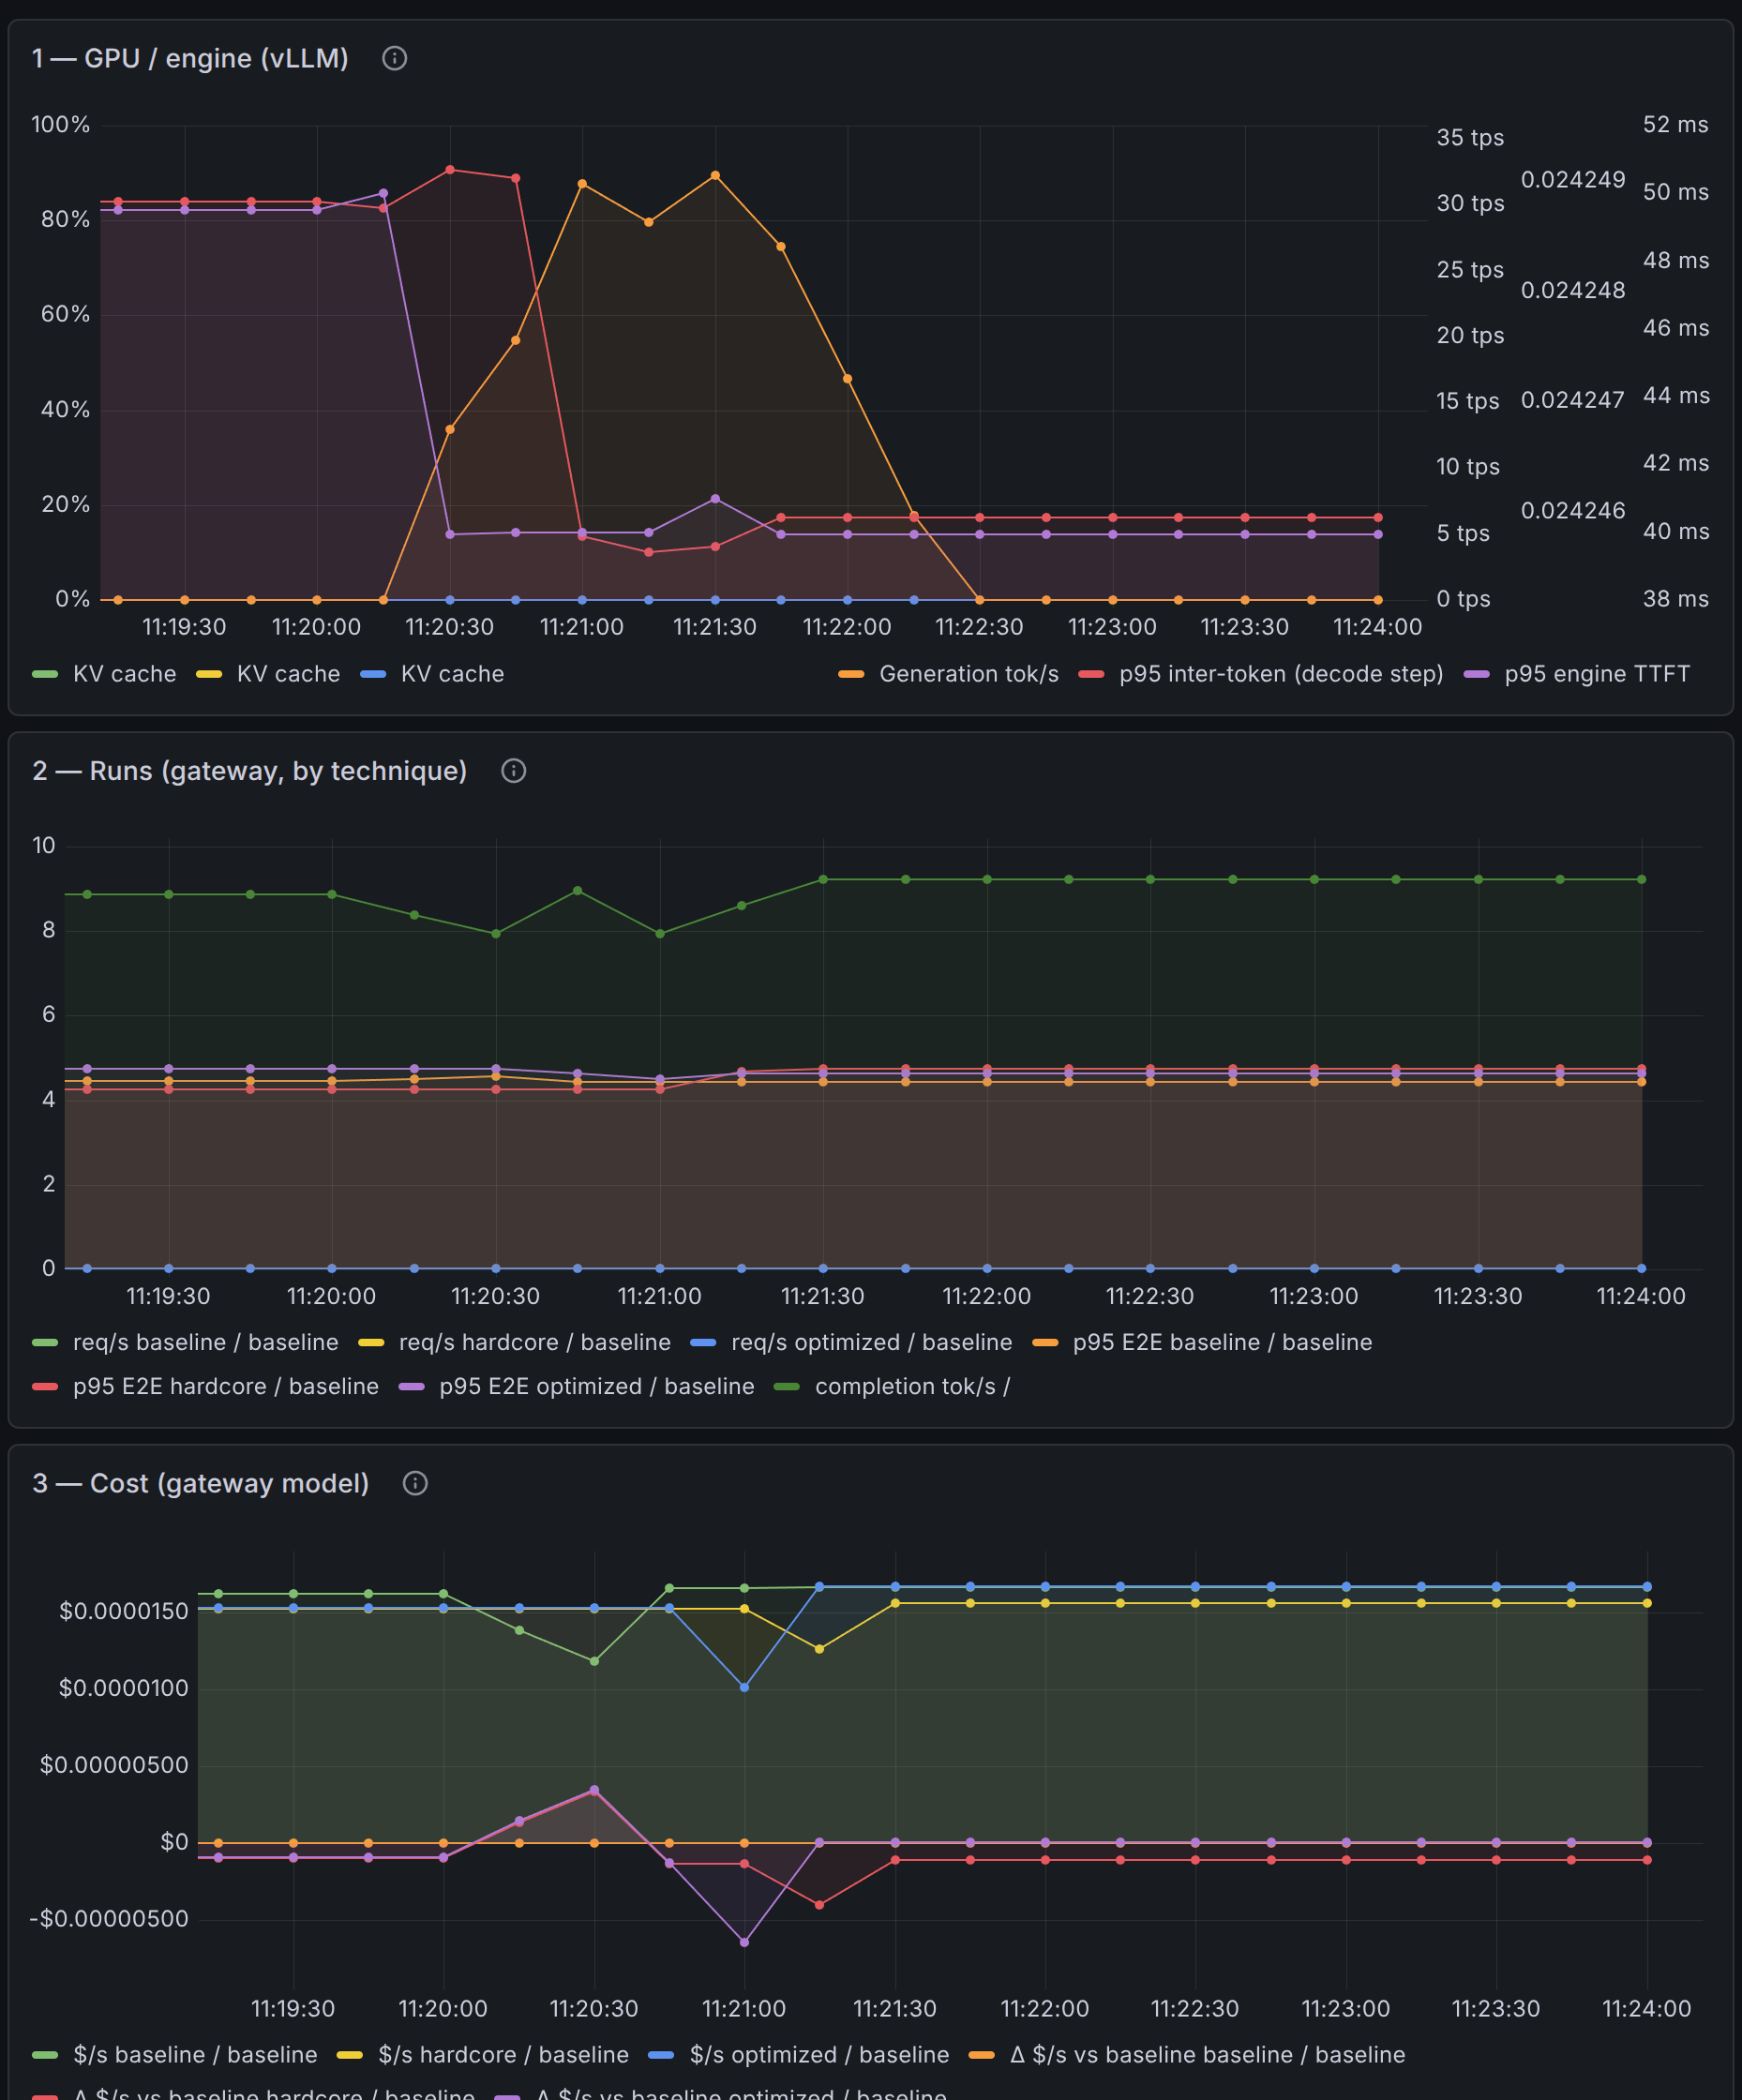

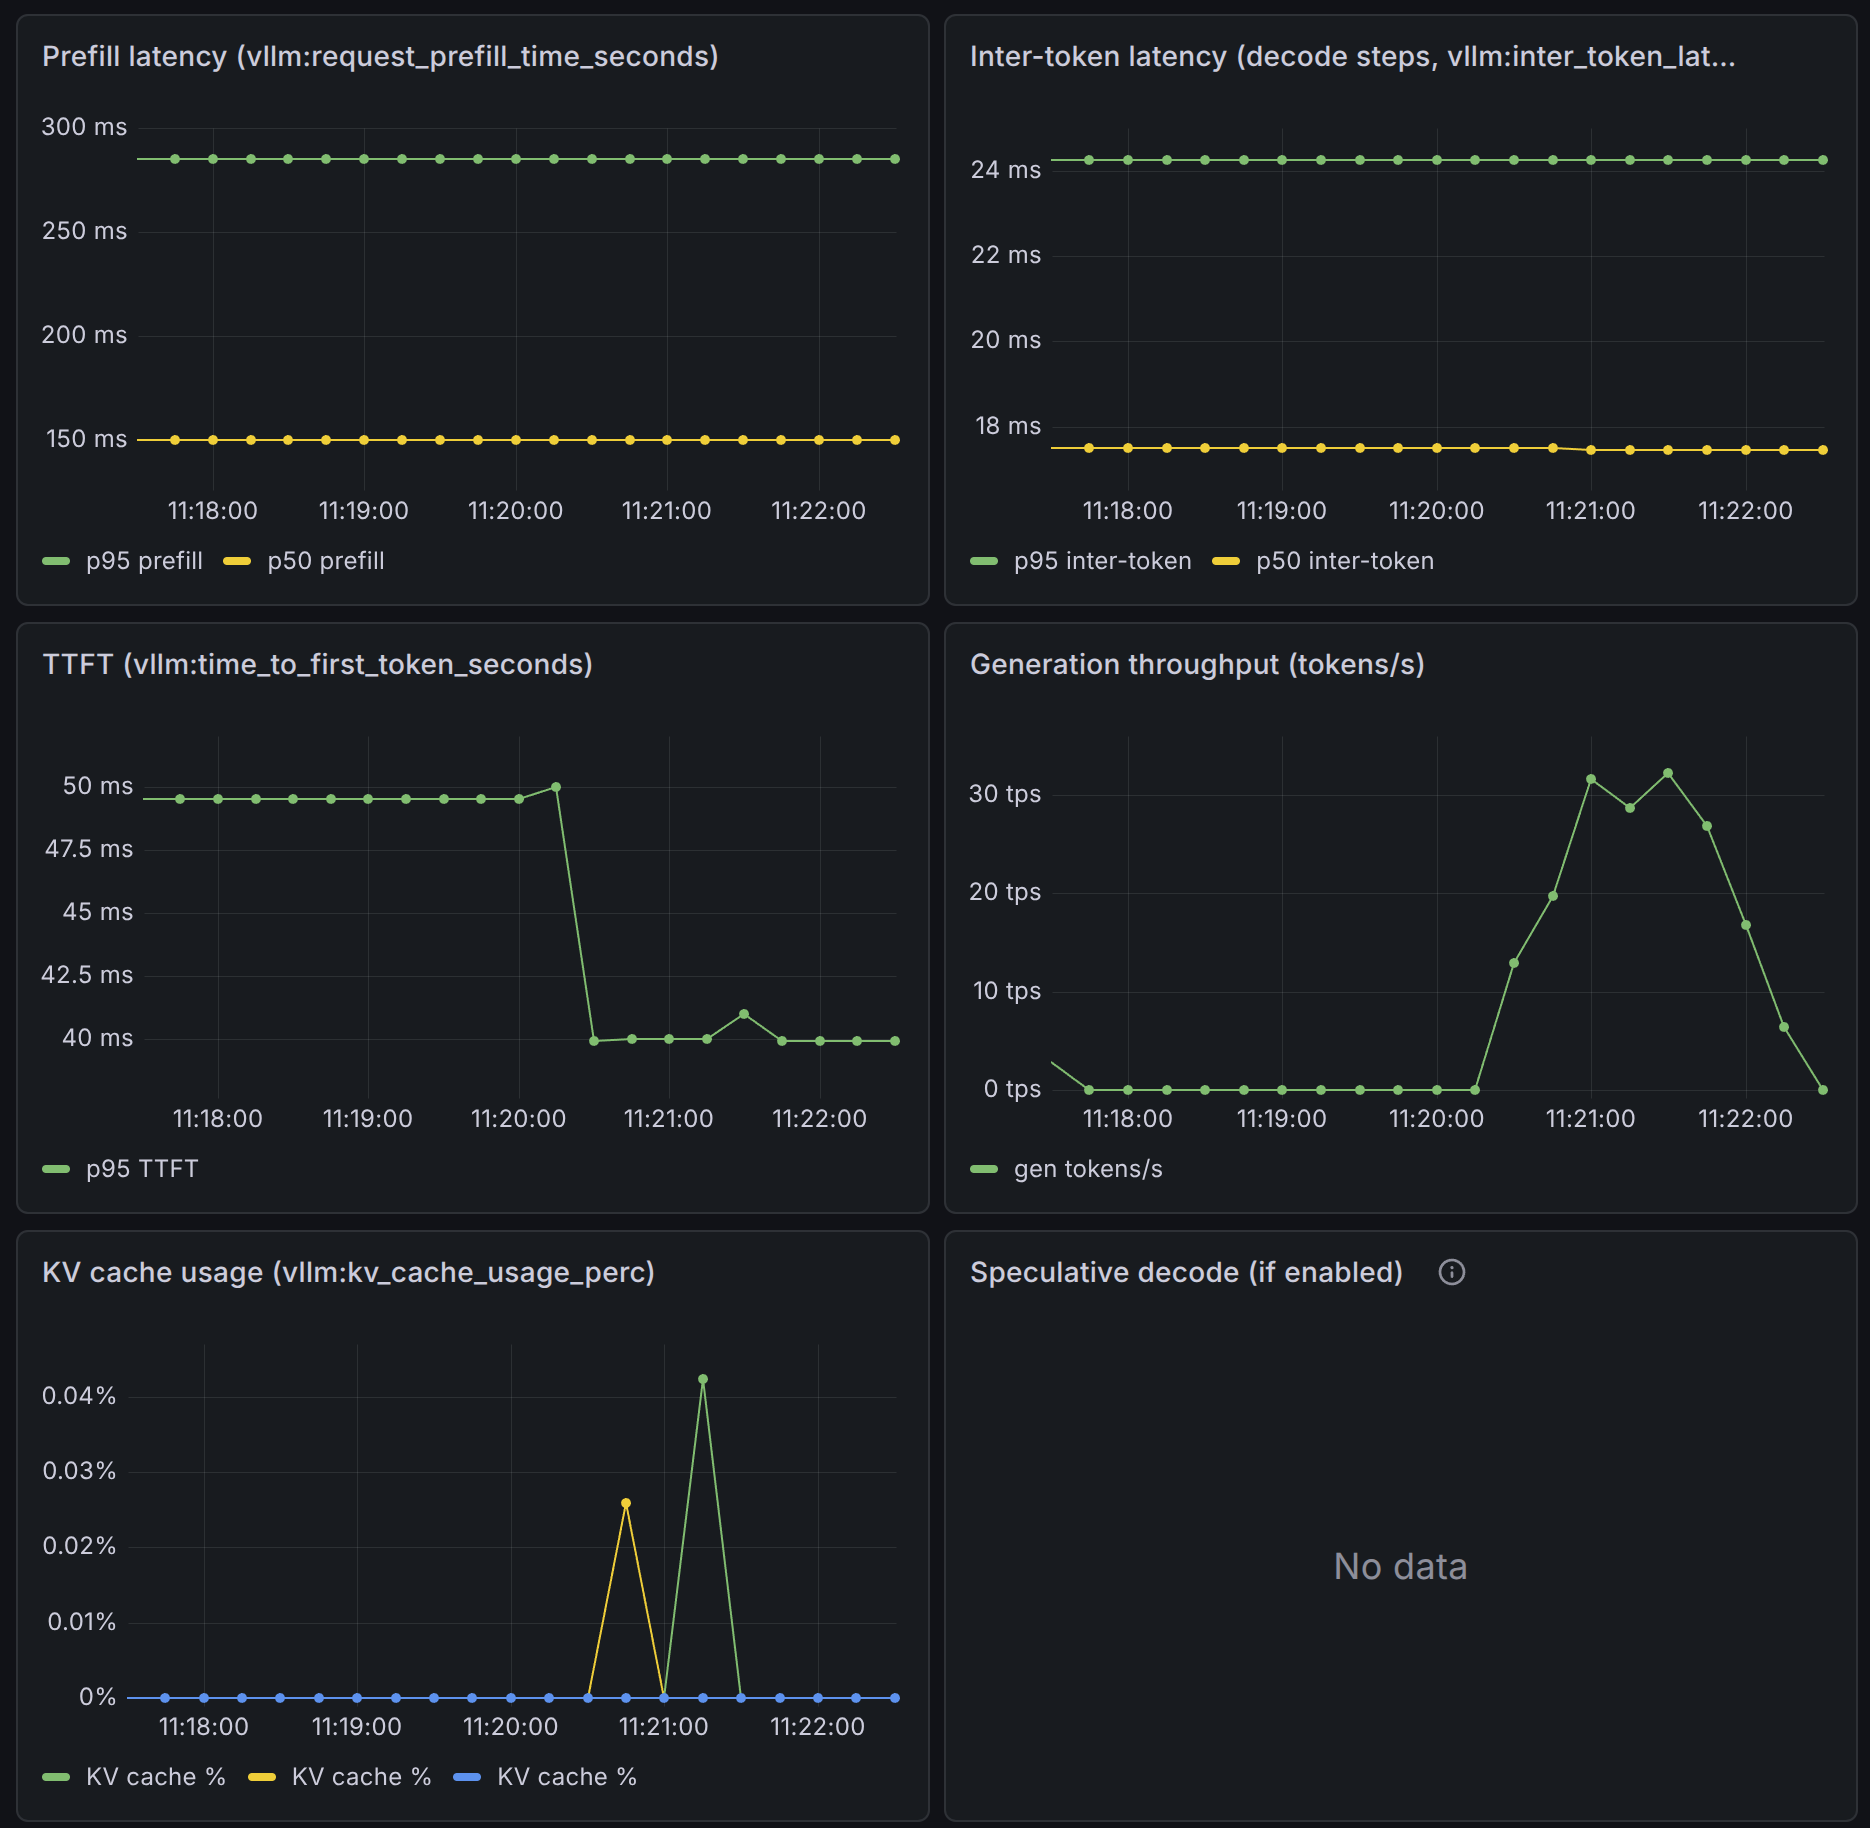

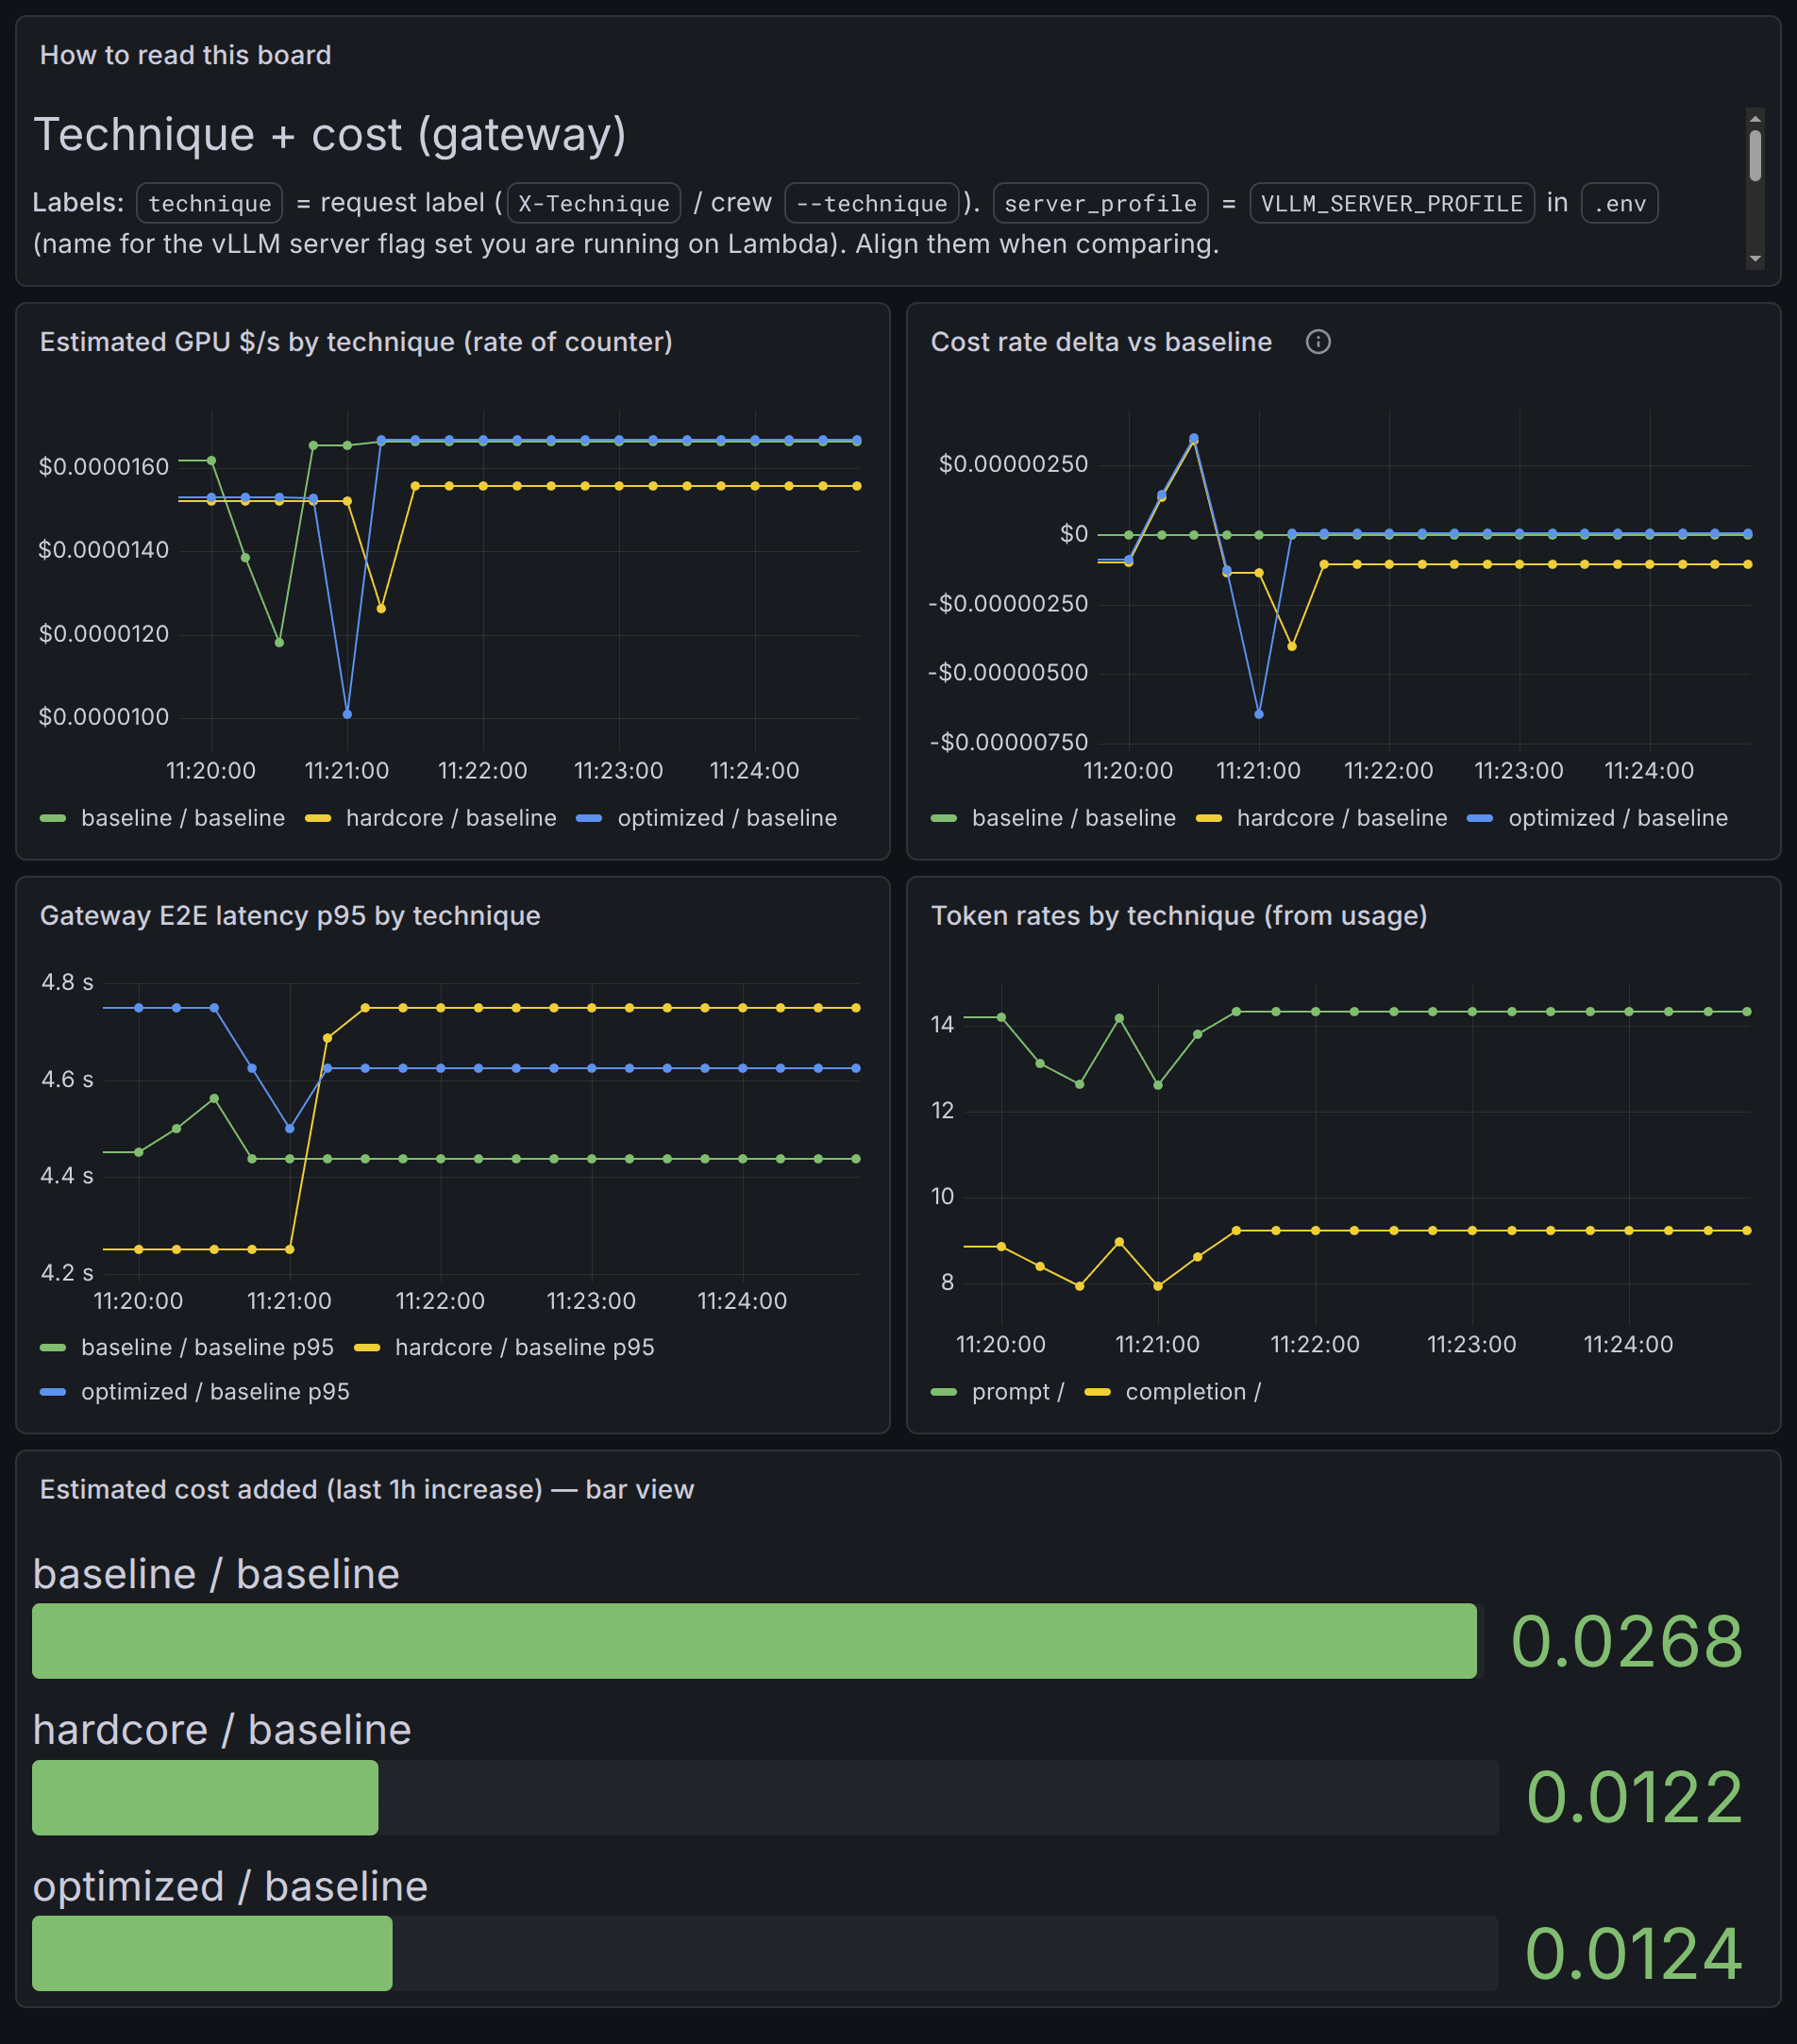

In [11]:
# ── Grafana dashboard screenshots ───────────────────────────────────────────
_screenshots = [
    ("grafana_proxy.png",     "Gateway — proxy timings + cost"),
    ("deep_diagnostics.png",  "Gateway — deep diagnostics"),
    ("gpu_runs.png",          "GPU runs overview"),
    ("prefill_vs_decode.png", "Prefill vs. decode latency breakdown"),
    ("technique_costs.png",   "Per-technique GPU cost comparison"),
    ("grafana_traces.png",    "Distributed traces (Jaeger)"),
]

for _fname, _title in _screenshots:
    _p = IMAGE_DIR / _fname
    if _p.exists():
        display(HTML(f"<h5>{_title}</h5>"))
        display(Image(filename=str(_p), width=900))
    else:
        display(HTML(
            '<div style="border:1px dashed #aaa;padding:12px;border-radius:4px;">'
            f'<b>📸 Screenshot placeholder:</b> <code>{_p}</code><br>'
            f'<i>{_title}</i><br>'
            '<small>Save a screenshot to this path and re-run the cell.</small>'
            '</div>'
        ))


### 5.3 Distributed Tracing (OpenTelemetry → Jaeger)

Tracing is **off by default** (zero overhead). Enable with `OTEL_TRACES_EXPORTER=otlp` in `.env`.

#### Span hierarchy for one crew run

```
crew.run                           service: crew         (crew.py)
│  attribute: llm.technique
│
└── chat.completions               service: inference-gateway  (main.py)
       attributes: technique, server_profile, http.status_code, backend
       events (in order):
         • validation.done          — body parsed, model + stream known
         • backend.selected         — backend name + routing reason (model_match / default_fallback)
         • backend.request.start    — about to call the upstream
         • stream.first_chunk       — first SSE data line received (ttft_s)   ← streaming only
         • stream.complete          — all chunks forwarded (chunks, completion_tokens, e2e_ms)
         • backend.response.complete— full JSON response received (non-streaming)

       [gap — vLLM 0.19 does not consume W3C traceparent]
       vLLM                         not traced (no child span)
```

#### vLLM trace gap

`_outgoing_headers()` injects the W3C `traceparent` header on every upstream request, but vLLM 0.19 does not instrument incoming HTTP requests or propagate the trace context. In Jaeger you will see the `crew.run → chat.completions` hierarchy clearly; the gateway→vLLM hop appears as a blank segment at the end of the span. The duration between `backend.request.start` and `backend.response.complete` / `stream.complete` events is the backend wall-clock time — visible as annotated event timestamps even without a child span.

#### How to enable

```bash
# Install OTel packages (once)
uv sync --group otel

# Start Jaeger via the monitoring stack
docker compose -f monitoring/docker-compose.yml up -d jaeger

# Enable in .env, then restart gateway and run crew
echo "OTEL_TRACES_EXPORTER=otlp" >> .env
uv run --group otel python main.py &
OTEl_TRACES_EXPORTER=otlp uv run --group otel --group crew python crew.py --technique chunked_prefill
```

Open **http://localhost:16686**, select service `inference-gateway`. The **Gateway — deep diagnostics** Grafana dashboard also has a live Traces panel at the bottom of the board (Jaeger is provisioned automatically as a datasource by the monitoring stack).

---
## Reflection (<300 words)

**Biggest surprise:** Gemma 4's heterogeneous attention head dimensions (256 for local, 512 for global layers) forced vLLM to fall back from FlashAttention to the Triton backend. This was not in the vLLM docs for 0.19.0 and only surfaced at serve-time. The practical impact was lower throughput (~20–40 tok/s on A10G) than similar-sized models with uniform head dimensions. The fix was using `--async-scheduling` and tuning batch budgets to keep the Triton backend from becoming the bottleneck.

**What broke first (and which metric caught it):** The first experiment run timed out because the Modal cold-start (image pull + weight download) exceeded the gateway's 120 s backend timeout. The metric that caught it was `gateway_errors_total{status_code="504"}` spiking to 1 immediately. Increasing `scaledown_window` to 15 minutes and raising the backend timeout in `config.yaml` fixed the issue for subsequent runs.

**Next steps for production:** Three changes would matter most:
1. **FP8 KV cache on H100** — moving to Hopper would unlock `--kv-cache-dtype fp8`, roughly halving KV memory usage and allowing `max_model_len=32768` or higher concurrent sequences on the same VRAM budget.
2. **Autoscaling** — replace `min_containers=max_containers=1` with a Modal autoscaler that scales to zero when idle and bursts to 3–5 containers under experiment load, making the cost SLO self-enforcing.
3. **Structured output + retry in the crew** — the Writer agent occasionally produces outputs slightly over 120 words; adding a Pydantic output schema to the CrewAI task would enforce the contract and eliminate silent SLO violations at the application layer.